# HDBSCAN — Kruskal & Borůvka, Unconstrained & Constrained

This notebook explains how the HDBSCAN clustering algorithm works using both **Kruskal's** and **Borůvka's** algorithms to build the Minimum Spanning Tree (MST), in both unconstrained and constrained (cannot-link) settings.

## The HDBSCAN Pipeline

HDBSCAN works in 5 steps. Steps 1–2 and 4–5 are **shared** across all variants. Step 3 (building the MST) is where Kruskal and Borůvka differ.

```
Raw Data / Distance Matrix
        │
        ▼
  ┌─────────────────────────────┐
  │  Step 1: Core Distances     │  ← shared
  │  Step 2: MR Distances       │  ← shared
  └─────────────────────────────┘
        │
        ▼
  ┌─────────────────────────────┐
  │  Step 3: Build MST          │  ← Kruskal OR Borůvka
  └─────────────────────────────┘
        │
        ▼
  ┌─────────────────────────────┐
  │  Step 4: Condensed Tree     │  ← shared
  │  Step 5: Extract Clusters   │  ← shared
  └─────────────────────────────┘
        │
        ▼
  Labels + Probabilities
```

---

## Steps 1–2: From Raw Data to Edges (Shared)

These steps are identical regardless of which MST algorithm is used. They transform the input into a set of **density-aware edges** that feed into the MST builder.

### Input

The Kruskal path takes a **precomputed distance matrix** (dense or sparse). The Borůvka path takes **raw feature vectors** and builds a KD-tree. Either way, the goal is the same: get pairwise distances between points.

### Step 1: Core Distances

For each point, find the distance to its **`min_samples`-th nearest neighbor**. This is its **core distance** — a measure of how dense the local neighborhood is.

$$\text{core}_k(i) = \text{distance to the } k\text{-th nearest neighbor of } i$$

- **Small core distance** → dense area (cluster interior)
- **Large core distance** → sparse area (outlier or boundary)

Code: `_core_distances_from_sparse_rows` (Kruskal) / computed from KNN graph (Borůvka)

### Step 2: Mutual Reachability (MR) Distances

For every pair of points, compute:

$$d_{\text{mr}}(i, j) = \max\bigl(\text{dist}(i,j),\;\text{core}(i),\;\text{core}(j)\bigr)$$

This inflates the distance if either endpoint is in a sparse area. The effect: edges within dense clusters stay cheap, edges involving outliers become expensive.

Code: `_mutual_reachability_edges_upper_triangle` (Kruskal) / computed inline during tree queries (Borůvka)

---

## Step 3a: Unconstrained Kruskal MST

Kruskal's algorithm takes the full list of MR-weighted edges and builds the MST by processing them from cheapest to most expensive.

**Algorithm:**

1. **Sort** all edges by MR weight (cheapest first)
2. **Initialize** a DSU (Disjoint Set Union / Union-Find) where every point starts as its own component
3. **Walk** the sorted edges:
   - If the two endpoints are in **different** components → **add** the edge to the MST and **merge** the components
   - If they're in the **same** component → **skip** (would create a cycle)
4. **Stop** after $N-1$ edges have been added

**DSU (Union-Find)** is a data structure that tracks which component each point belongs to. It supports `find(x)` (get the root of x's component) and `union(a, b)` (merge two components). With union-by-rank and path compression, both operations run in nearly $O(1)$.

**Complexity:** Sorting the $O(N^2)$ edges dominates → $O(N^2 \log N)$.

Code: `_kruskal_mst_unconstrained`

---

## Step 3b: Constrained Kruskal MST

The constrained version adds **cannot-link constraints** — pairs of points that must not end up in the same cluster. The MST construction changes in two ways:

**What changes from 3a:**

1. **Direct pair check:** Before adding an edge $(a, b)$, check if $a$ and $b$ are a cannot-link pair. If so, **skip** the edge.
2. **Component-level check:** Even if $a$ and $b$ themselves aren't a cannot-link pair, merging their components might put two *other* constrained points into the same component. So before merging, check whether *any* point in component A has a cannot-link with *any* point in component B. If so, **skip** the edge.

Everything else (sorting, DSU, greedy walk) stays the same. The result is a **minimum spanning forest** — it may have fewer than $N-1$ edges if constraints prevent full connectivity.

Code: `_kruskal_mst_constrained_hard`

---

## Step 3c: Unconstrained Borůvka MST

Borůvka's algorithm takes **raw feature vectors** (not a precomputed distance matrix) and builds the MST using a KD-tree for fast nearest-neighbor lookups. Instead of sorting all edges up front, it works in **rounds**, each round finding the cheapest outgoing edge for every component simultaneously.

**Algorithm:**

1. **Build a KD-tree** from the raw feature vectors
2. **KNN initialization:** Query each point's k nearest neighbors from the KD-tree to get core distances. For each point, find the nearest neighbor whose core distance is ≤ the point's own core distance, compute the MR weight, and propose that edge. Merge the accepted edges via DSU — this quickly reduces the number of components.
3. **Borůvka rounds** (repeat until one component remains):
   - For each point, run a **component-aware KD-tree query** — search for the nearest point that is in a *different* component, using MR distance. The query prunes subtrees where every point belongs to the same component as the query point (or where the lower-bound distance already exceeds the best known edge).
   - For each component, keep only the **cheapest** proposed edge (via a per-component best-edge dictionary).
   - **Add** the winning edges to the MST and **merge** the corresponding components via DSU.
   - **Update** the component labels on both points and KD-tree nodes.
4. Return the MST edges (converting squared distances back to regular distances).

**Key difference from Kruskal:** Borůvka never materializes all $O(N^2)$ edges. The KD-tree prunes most of the search space, so each round is roughly $O(N \log N)$. With $O(\log N)$ rounds, the total is $O(N \log^2 N)$ — much faster for large datasets.

Code: `parallel_boruvka` (in `boruvka.py`)

---

## Step 3d: Constrained Borůvka MST

The constrained version adds **cannot-link constraints** (in CSR format) to the Borůvka loop. Three things change from 3c:

**What changes from 3c:**

1. **KD-tree query skips constrained neighbors:** During the component-aware query, if the candidate neighbor has a cannot-link with the query point, that candidate is skipped — it is never proposed as an edge.

2. **Component merge checks constraints:** Before merging two components, the algorithm checks whether *any* point in component A has a cannot-link with *any* point in component B (using a linked-list DSU that can iterate over all members of a component). If a violation exists, the merge is blocked.

3. **`fix_violations` after each round:** Even with the above checks, multiple merges in a single round can create transitive violations (A merges with B, B merges with C, but A↔C is a cannot-link). After each round, `fix_violations` scans the current MST edges for any component that now contains a cannot-link pair. When found, it removes the **heaviest edge from that round** that contributed to the violating component, rebuilds the DSU without that edge, and re-checks. This repeats until no violations remain.

The result is a **minimum spanning forest** — constraints may prevent full connectivity. Disconnected components are later bridged with infinite-weight sentinel edges so the condensed tree can process them.

**Note:** Because `fix_violations` removes the heaviest round-edge (not necessarily the edge causally responsible for the violation), constrained Borůvka can produce different forests than constrained Kruskal on the same data.

Code: `parallel_boruvka` (in `boruvka_constrained_new.py`)

---

## Steps 4–5: From MST to Clusters (Shared)

Once we have the MST (from either Kruskal or Borůvka), the remaining steps are identical.

### Step 4a: Linkage Tree

Sort the MST edges by weight and replay the merges into a **dendrogram** — a binary tree where each internal node represents two components merging at a given distance. Each merge creates a virtual node (numbered $\geq N$) that records `[left_child, right_child, distance, merged_size]`.

Code: `mst_to_linkage_tree`

### Step 4b: Condensed Tree

The dendrogram records every single-point merge, which is too granular. The condensed tree simplifies it using `min_cluster_size`:

- Walk the dendrogram **top-down**
- At each split, check if **both** children have $\geq$ `min_cluster_size` points
  - **Both large enough** → real cluster split (two new child clusters born)
  - **One too small** → those points "fall out" as noise; the cluster continues as the larger child
  - **Both too small** → all remaining points fall out

Distances are converted to **lambda** ($\lambda = 1 / \text{distance}$) — a density scale where high $\lambda$ = dense/fine and low $\lambda$ = sparse/coarse.

Code: `condense_tree`

### Step 5a: Stability Scoring

Each cluster gets a **stability score** measuring how long it persists across density scales:

$$\text{stability}(C) = \sum_{p \in C} (\lambda_{\text{p fell out}} - \lambda_{\text{C born}})$$

Clusters that hold their points over a wide $\lambda$ range are stable. Clusters that immediately shed points are not.

Code: `score_condensed_tree_nodes`

### Step 5b: EOM Cluster Selection

**Excess of Mass (EOM)** picks the best non-overlapping clusters. Starting from the leaves of the cluster tree and working up:

> *Is this cluster's own stability ≥ the combined stability of its children?*

- **Yes** → select this cluster, deselect all descendants
- **No** → keep the children (the finer split is more stable)

Code: `extract_eom_clusters`

### Step 6: Labels & Probabilities

- **Labels:** Each point gets the label of its selected cluster, or **-1 (noise)** if it doesn't belong to any. Code: `get_cluster_label_vector`
- **Probabilities:** Confidence score $\in [0, 1]$, computed as $\lambda_{\text{point}} / \lambda_{\max}$ of the cluster. Points that persisted until the densest moment get high probability. Code: `get_point_membership_strength_vector`

---

### Summary

| Step | Shared? | Code Function | What It Does |
|------|---------|--------------|-------------|
| 0 | Kruskal only | `_ensure_csr_distance_matrix` | Normalizes input to symmetric CSR |
| 1 | Shared | `_core_distances_from_sparse_rows` | Distance to k-th NN → local density |
| 2 | Shared | `_mutual_reachability_edges_upper_triangle` | Density-aware edge weights |
| 3a | **Kruskal** | `_kruskal_mst_unconstrained` | Sort edges + greedy DSU |
| 3b | **Kruskal (constrained)** | `_kruskal_mst_constrained_hard` | 3a + cannot-link pair & component checks |
| 3c | **Borůvka** | `parallel_boruvka` (boruvka.py) | KD-tree + component-wise NN rounds |
| 3d | **Borůvka (constrained)** | `parallel_boruvka` (boruvka_constrained_new.py) | 3c + CL query skip, merge check, fix_violations |
| 4a | Shared | `mst_to_linkage_tree` | MST → dendrogram |
| 4b | Shared | `condense_tree` | Dendrogram → simplified cluster hierarchy |
| 5 | Shared | `score_condensed_tree_nodes` + `extract_eom_clusters` | Stability → cluster selection |
| 6 | Shared | `get_cluster_label_vector` + `get_point_membership_strength_vector` | Final labels + probabilities |

---

## Worked Example

All examples use the **same 8-point graph** so we can directly compare how each MST algorithm variant produces different (or identical) results.

We use `min_samples = 2` and `min_cluster_size = 3`.

The layout: two tight clusters of 3 points each, plus 2 outliers.

```
        6
       · ·        Cluster B (pts 4, 5, 6)
      4   5


                7  ← outlier (far right)

  2
 · ·               Cluster A (pts 0, 1, 2)
0   1

          3        ← outlier (middle)
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import squareform, pdist

# 8 points in 2D
points = np.array([
    # Cluster A (lower-left, tight)
    [1.0, 1.0],   # 0
    [1.6, 1.0],   # 1
    [1.3, 1.8],   # 2

    # Outlier (middle)
    [3.0, 2.0],   # 3

    # Cluster B (upper-right, tight)
    [5.0, 5.0],   # 4
    [5.6, 5.0],   # 5
    [5.3, 5.8],   # 6

    # Outlier (far right)
    [7.5, 3.5],   # 7
])

n_points = len(points)
min_samples = 2
min_cluster_size = 3

print(f"N = {n_points} points,  min_samples = {min_samples},  min_cluster_size = {min_cluster_size}")

N = 8 points,  min_samples = 2,  min_cluster_size = 3


/var/folders/25/jsfr4z_n287567y95vp2zgn40000gn/T/ipykernel_85065/349113600.py:16: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(points[i, 0], points[i, 1], s=120, c=color, marker=marker, zorder=5, edgecolors='black', linewidth=0.5)


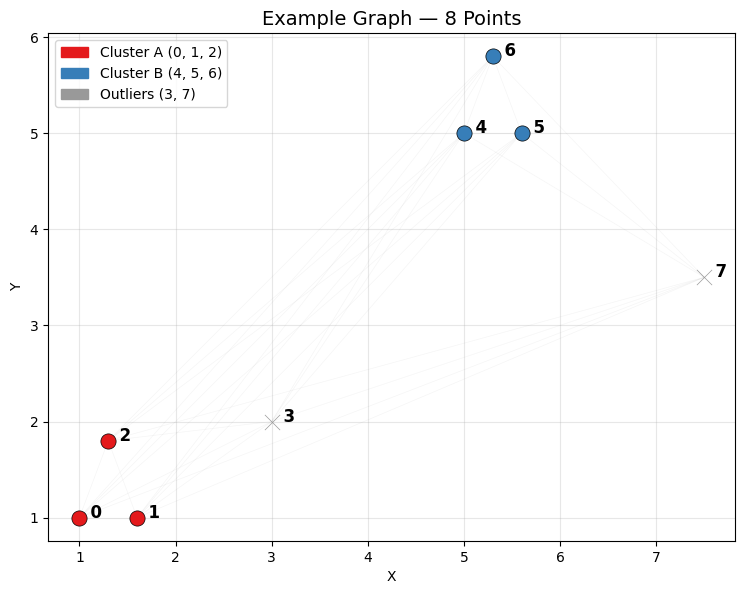

In [2]:
# Visualize the raw data
fig, ax = plt.subplots(figsize=(8, 6))

# Color groups for visual clarity
cluster_a = [0, 1, 2]
cluster_b = [4, 5, 6]
outliers = [3, 7]

for i in range(n_points):
    if i in cluster_a:
        color, marker = '#e41a1c', 'o'
    elif i in cluster_b:
        color, marker = '#377eb8', 'o'
    else:
        color, marker = '#999999', 'x'
    ax.scatter(points[i, 0], points[i, 1], s=120, c=color, marker=marker, zorder=5, edgecolors='black', linewidth=0.5)
    ax.annotate(f'  {i}', points[i], fontsize=12, fontweight='bold')

# Draw all pairwise edges lightly
for i in range(n_points):
    for j in range(i + 1, n_points):
        ax.plot(
            [points[i, 0], points[j, 0]],
            [points[i, 1], points[j, 1]],
            color='grey', alpha=0.08, linewidth=0.5
        )

ax.legend(
    handles=[
        mpatches.Patch(color='#e41a1c', label='Cluster A (0, 1, 2)'),
        mpatches.Patch(color='#377eb8', label='Cluster B (4, 5, 6)'),
        mpatches.Patch(color='#999999', label='Outliers (3, 7)'),
    ],
    loc='upper left', fontsize=10,
)
ax.set_title('Example Graph — 8 Points', fontsize=14)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

### Steps 1–2: Core Distances & MR Edges (Shared Setup)

Using the 8-point graph above, we compute core distances and MR-weighted edges. This is the same input for all four MST variants.

*(Code and walkthrough to follow)*

---

### Step 3a Example: Unconstrained Kruskal MST

Using the MR edges from above, run Kruskal's greedy sort-and-merge to produce the MST.

*(Code and walkthrough to follow)*

---

### Step 3b Example: Constrained Kruskal MST

Same MR edges, but now with cannot-link constraints. We see which edges get blocked and how the MST differs.

*(Code and walkthrough to follow)*

---

### Step 3c Example: Unconstrained Borůvka MST

Same data, but Borůvka builds the MST through component-wise nearest-neighbor rounds instead of sorting all edges.

*(Code and walkthrough to follow)*

---

### Step 3d Example: Constrained Borůvka MST

Same data with the same cannot-link constraints as 3b, but using Borůvka. We compare the resulting MST against constrained Kruskal.

*(Code and walkthrough to follow)*

---

### Steps 4–6: From MST to Clusters (Shared)

We take the MST from each variant above and run the shared pipeline: linkage tree → condensed tree → stability → EOM → labels & probabilities. We compare the final clusters side-by-side.

*(Code and walkthrough to follow)*